In [1]:
# CELL 0: CÀI ĐẶT THƯ VIỆN
!pip install rank_bm25 sentence-transformers scikit-learn torch numpy pandas tqdm matplotlib tabulate

In [2]:
# CELL 1: ĐỊNH NGHĨA ĐƯỜNG DẪN VÀ HẰNG SỐ
import os
import random
import numpy as np
import torch

AMAZON_DIR = '/content/drive/MyDrive/amazon/'
CLEANED_METADATA_1 = '/content/drive/MyDrive/amazon/cleaned_mapped_metadata_1/'
CLEANED_METADATA_2 = '/content/drive/MyDrive/amazon/cleaned_mapped_metadata_2/'
MASTER_METADATA = '/content/drive/MyDrive/amazon/master_metadata_tong_hop.csv'

AMAZON_DETAILS = [
    '/content/drive/MyDrive/amazon/laptop_details.jsonl',
    '/content/drive/MyDrive/amazon/smartphone_details.jsonl',
    '/content/drive/MyDrive/amazon/desktop_details.jsonl',
    '/content/drive/MyDrive/amazon/monitor_details.jsonl',
    '/content/drive/MyDrive/amazon/cpu_details_1.jsonl',
    '/content/drive/MyDrive/amazon/cpu_details_2.jsonl',
    '/content/drive/MyDrive/amazon/gpu_details.jsonl',
    '/content/drive/MyDrive/amazon/headphone_details.jsonl',
]

MODEL_DIR = '/content/drive/MyDrive/amazon_gcp_prepared_data_improved/'
DSSM_PATH = MODEL_DIR + 'dssm_lan_2/dssm_best.pt'
GCN_PATH = MODEL_DIR + 'gcn_lan_3/gcn_best.pt'
LLM_CHGNN_PATH = MODEL_DIR + 'results_llm_chgnn_2/llm_chgnn_best.pt'

ITEM_EMBEDDINGS_PATH = MODEL_DIR + 'item_embeddings.npy'
ITEM_INDEX_PATH = MODEL_DIR + 'item_index.pkl'
LLM_CHGNN_EMBEDDINGS_PATH = MODEL_DIR + 'llm_chgnn_embeddings/llm_chgnn_embeddings.npy'
LLM_CHGNN_INDEX_PATH = MODEL_DIR + 'llm_chgnn_embeddings/llm_chgnn_index.pkl'

OUTPUT_DIR = '/content/drive/MyDrive/amazon/prepared_data_improved/'

SEED = 42
NUM_CANDIDATES = 100
HR_K = 10
NDCG_K = 10

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [3]:
# CELL 2: ĐỌC VÀ XỬ LÝ DỮ LIỆU ĐẦU VÀO VÀ ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH
from google.colab import drive
import pandas as pd
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

vn_catalog = {}
vn_ids = []
amz_details = []
master_df = pd.DataFrame()

if os.path.exists(ITEM_EMBEDDINGS_PATH):
    item_embeddings = np.load(ITEM_EMBEDDINGS_PATH, mmap_mode='r')
else:
    item_embeddings = np.random.rand(1000, 768)

if os.path.exists(ITEM_INDEX_PATH):
    with open(ITEM_INDEX_PATH, 'rb') as f:
        id_to_idx = pickle.load(f)
else:
    id_to_idx = {}

sbert_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

def evaluate_metrics(true_id, candidate_ids, scores):
    ranked = [cid for _, cid in sorted(zip(scores, candidate_ids), reverse=True)]
    hr = 1.0 if true_id in ranked[:HR_K] else 0.0
    ndcg = 0.0
    if true_id in ranked[:HR_K]:
        idx = ranked[:HR_K].index(true_id)
        ndcg = 1.0 / np.log2(idx + 2)
    return hr, ndcg

# =====================================================================
# CÁC HÀM HỖ TRỢ HYBRID VÀ HYPERGRAPH
# =====================================================================

def normalize_specs(specs):
    if not specs or not isinstance(specs, dict):
        return {}
    return {str(k): str(v) for k, v in specs.items() if k is not None and v is not None}

def build_incidence_matrix(item_specs_list, attr_to_idx, device):
    N = len(item_specs_list)
    E = len(attr_to_idx)
    H = torch.zeros((N, E), dtype=torch.float32, device=device)
    if E == 0: return H

    for node_idx, specs in enumerate(item_specs_list):
        specs = normalize_specs(specs)
        if not specs:
            continue
        for k, v in specs.items():
            attr = f"{str(k).strip().lower()}:{str(v).strip().lower()}"
            attr_idx = attr_to_idx.get(attr)
            if attr_idx is not None:
                H[node_idx, attr_idx] = 1.0
    return H

def compute_attribute_match(q_specs, c_specs):
    if not q_specs or not c_specs: return 0.0
    matches, total = 0, 0
    important_keys = ['cong nghe cpu', 'chip xu ly', 'ram', 'o cung', 'brand', 'thuong hieu']
    q_norm = normalize_specs(q_specs)
    c_norm = normalize_specs(c_specs)
    for key in important_keys:
        if key in q_norm and key in c_norm:
            total += 1
            if str(q_norm[key]).lower() == str(c_norm[key]).lower():
                matches += 1
    return matches / max(total, 1)

# Tải Attribute Vocab cho LLM-CHGNN
ATTR_VOCAB_PATH = MODEL_DIR + 'results_llm_chgnn_2/llm_chgnn_attr_vocab.json'
if os.path.exists(ATTR_VOCAB_PATH):
    with open(ATTR_VOCAB_PATH, 'r', encoding='utf-8') as f:
        attr_vocab = json.load(f)
    attr_to_idx = {attr: i for i, attr in enumerate(attr_vocab)}
else:
    attr_to_idx = {}

# =====================================================================
# ĐỊNH NGHĨA KIẾN TRÚC MẠNG NEURAL (Cập nhật chuẩn xác từ Kien_truc_mo_hinh.md)
# =====================================================================

class BatchedGCN(nn.Module):
    def __init__(self, in_features=768, hidden_features=256, out_features=128, knn_threshold=0.3):
        super(BatchedGCN, self).__init__()
        self.knn_threshold = knn_threshold
        self.W1 = nn.Linear(in_features, hidden_features)
        self.W2 = nn.Linear(hidden_features, out_features)
        self.dropout = nn.Dropout(0.3)

    def forward(self, X):
        sim_matrix = F.cosine_similarity(X.unsqueeze(2), X.unsqueeze(1), dim=3)
        A = (sim_matrix > self.knn_threshold).float()

        I = torch.eye(X.size(1), device=X.device).unsqueeze(0).expand_as(A)
        A = A + I

        D = torch.sum(A, dim=2)
        D_inv_sqrt = torch.pow(D, -0.5)
        D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.0

        D_mat_inv_sqrt = torch.diag_embed(D_inv_sqrt)
        A_norm = torch.bmm(torch.bmm(D_mat_inv_sqrt, A), D_mat_inv_sqrt)

        H1 = F.relu(self.W1(torch.bmm(A_norm, X)))
        H1 = self.dropout(H1)
        H2 = self.W2(torch.bmm(A_norm, H1))

        return F.normalize(H2, p=2, dim=2)

class DSSM(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, out_dim=128):
        super(DSSM, self).__init__()
        self.amazon_tower = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, out_dim)
        )
        self.vn_tower = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, amz_emb, vn_emb):
        amz_rep = F.normalize(self.amazon_tower(amz_emb), p=2, dim=1)
        vn_rep = F.normalize(self.vn_tower(vn_emb), p=2, dim=1)
        return torch.sum(amz_rep * vn_rep, dim=1)

class HypergraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super(HypergraphConv, self).__init__()
        self.W = nn.Linear(in_features, out_features)
        self.self_loop = nn.Linear(in_features, out_features, bias=False)

    def forward(self, X, H):
        D_v = torch.sum(H, dim=2).clamp(min=1.0)
        D_e = torch.sum(H, dim=1).clamp(min=1.0)

        X_norm = X * torch.pow(D_v, -0.5).unsqueeze(-1)
        edge_features = torch.bmm(H.transpose(1, 2), X_norm)
        edge_features = edge_features * torch.pow(D_e, -1.0).unsqueeze(-1)
        out = torch.bmm(H, edge_features)
        out = out * torch.pow(D_v, -0.5).unsqueeze(-1)

        out = self.W(out) + self.self_loop(X)
        return F.relu(out)

class LLM_CHGNN(nn.Module):
    def __init__(self, in_features=768, hidden_features=256, out_features=128):
        super(LLM_CHGNN, self).__init__()
        self.conv1 = HypergraphConv(in_features, hidden_features)
        self.conv2 = HypergraphConv(hidden_features, out_features)
        self.dropout = nn.Dropout(0.3)

    def forward(self, X, H):
        X = self.dropout(self.conv1(X, H))
        X = self.conv2(X, H)
        return F.normalize(X, p=2, dim=2)

# =====================================================================
# HÀM TRÍCH XUẤT VÀ NẠP WEIGHTS TỪ CHECKPOINT
# =====================================================================

def load_real_pytorch_model(path, model_instance):
    if not os.path.exists(path):
        print(f"Không tìm thấy checkpoint: {path}")
        return model_instance

    try:
        checkpoint = torch.load(path, map_location=torch.device('cpu'), weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            state_dict = checkpoint['model_state']
            new_state_dict = {}
            for k, v in state_dict.items():
                name = k[7:] if k.startswith('module.') else k
                new_state_dict[name] = v
            model_instance.load_state_dict(new_state_dict)
            print(f"Đã nạp weights thành công từ {path} (Epoch: {checkpoint.get('epoch', 'N/A')})")
        else:
            model_instance.load_state_dict(checkpoint)
            print(f"Đã nạp weights trực tiếp thành công từ {path}")
    except Exception as e:
        print(f"Lỗi khi nạp model {path}: {str(e)}")

    model_instance.eval()
    return model_instance

dssm_model = load_real_pytorch_model(DSSM_PATH, DSSM(input_dim=768, hidden_dim=256, out_dim=128))
gcn_model = load_real_pytorch_model(GCN_PATH, BatchedGCN(in_features=768, hidden_features=256, out_features=128, knn_threshold=0.3))
llm_chgnn_model = load_real_pytorch_model(LLM_CHGNN_PATH, LLM_CHGNN(in_features=768, hidden_features=256, out_features=128))

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Đã nạp weights thành công từ /content/drive/MyDrive/amazon_gcp_prepared_data_improved/dssm_lan_2/dssm_best.pt (Epoch: 1)
Đã nạp weights thành công từ /content/drive/MyDrive/amazon_gcp_prepared_data_improved/gcn_lan_3/gcn_best.pt (Epoch: 3)
Đã nạp weights thành công từ /content/drive/MyDrive/amazon_gcp_prepared_data_improved/results_llm_chgnn_2/llm_chgnn_best.pt (Epoch: 2)


In [4]:
# CELL 3: TẠO TẬP TEST KỊCH BẢN 1 — CROSS-DOMAIN (AMAZON → VN)
import glob

vn_catalog = {}
ground_truth_map = {}

for path in [CLEANED_METADATA_1, CLEANED_METADATA_2]:
    if os.path.exists(path):
        for file_path in glob.glob(os.path.join(path, "*.jsonl")):
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    data = json.loads(line)
                    pid = data.get('product_id')
                    asin = data.get('asin')
                    text = f"{data.get('product_name', '')} {data.get('specifications', '')} {data.get('description', '')}".lower().replace('\n', ' ')
                    if pid:
                        vn_catalog[pid] = text
                        if asin:
                            ground_truth_map[asin] = pid

scenario_1_dataset = []
for amz_file in AMAZON_DETAILS:
    if os.path.exists(amz_file):
        with open(amz_file, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                asin = data.get('asin')
                if asin in ground_truth_map:
                    q_text = f"{data.get('title', '')} {data.get('features', '')} {data.get('description', '')}".lower().replace('\n', ' ')
                    true_id = ground_truth_map[asin]

                    all_pids = list(vn_catalog.keys())
                    negatives = [p for p in all_pids if p != true_id]
                    sampled_negs = random.sample(negatives, min(len(negatives), NUM_CANDIDATES - 1))
                    candidates = [true_id] + sampled_negs
                    random.shuffle(candidates)

                    scenario_1_dataset.append({
                        'query_id': asin,
                        'query_text': q_text,
                        'true_vn_id': true_id,
                        'candidate_ids': candidates,
                        'candidate_texts': [vn_catalog[cid] for cid in candidates]
                    })

os.makedirs(OUTPUT_DIR, exist_ok=True)
with open(os.path.join(OUTPUT_DIR, 'benchmark_scenario_1_cross_domain.pkl'), 'wb') as f:
    pickle.dump(scenario_1_dataset, f)

In [5]:
# CELL 4: CHẠY 10 MÔ HÌNH TRÊN KỊCH BẢN 1
from tqdm import tqdm

models_list = ['MF', 'LightGCN', 'GCN', 'HGNN', 'TF-IDF', 'BM25', 'SBERT', 'DSSM', 'Hybrid', 'LLM-CHGNN']
results_scenario_1 = {m: {'hr': [], 'ndcg': []} for m in models_list}

for item in tqdm(scenario_1_dataset, desc="Evaluating Scenario 1"):
    true_id = item['true_vn_id']
    c_ids = item['candidate_ids']
    c_texts = item['candidate_texts']
    q_text = item['query_text']
    q_id = item.get('query_id', '')

    q_specs = item.get('query_specs', {})
    c_specs_list = item.get('candidate_specs', [{}] * len(c_ids))
    q_cat = item.get('query_category', '')
    c_cats = item.get('candidate_categories', [''] * len(c_ids))

    # TF-IDF
    tfidf = TfidfVectorizer()
    try:
        tfidf_mat = tfidf.fit_transform(c_texts + [q_text])
        sims = (tfidf_mat[:-1] * tfidf_mat[-1].T).toarray().flatten()
    except:
        sims = np.zeros(len(c_ids))
    hr, ndcg = evaluate_metrics(true_id, c_ids, sims)
    results_scenario_1['TF-IDF']['hr'].append(hr)
    results_scenario_1['TF-IDF']['ndcg'].append(ndcg)

    # BM25
    bm25_local = BM25Okapi([t.split(" ") for t in c_texts])
    bm25_scores = bm25_local.get_scores(q_text.split(" "))
    hr, ndcg = evaluate_metrics(true_id, c_ids, bm25_scores)
    results_scenario_1['BM25']['hr'].append(hr)
    results_scenario_1['BM25']['ndcg'].append(ndcg)

    # SBERT
    q_emb = sbert_model.encode(q_text, convert_to_numpy=True)
    c_embs = sbert_model.encode(c_texts, convert_to_numpy=True)

    q_norm = q_emb / (np.linalg.norm(q_emb) + 1e-9)
    c_norm = c_embs / (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-9)
    sbert_scores = np.dot(c_norm, q_norm)
    hr, ndcg = evaluate_metrics(true_id, c_ids, sbert_scores)
    results_scenario_1['SBERT']['hr'].append(hr)
    results_scenario_1['SBERT']['ndcg'].append(ndcg)

    # Hybrid
    bm25_norm_scores = bm25_scores / (np.max(bm25_scores) + 1e-6)
    attr_scores = np.array([compute_attribute_match(q_specs, cs) for cs in c_specs_list])
    cat_scores = np.array([1.0 if cat == q_cat else 0.0 for cat in c_cats])
    hybrid_scores = 0.2 * bm25_norm_scores + 0.3 * sbert_scores + 0.3 * attr_scores + 0.2 * cat_scores
    hr, ndcg = evaluate_metrics(true_id, c_ids, hybrid_scores)
    results_scenario_1['Hybrid']['hr'].append(hr)
    results_scenario_1['Hybrid']['ndcg'].append(ndcg)

    # LLM-CHGNN (2-Stage Re-ranking)
    ranked_by_sbert = [cid for _, cid in sorted(zip(sbert_scores, c_ids), reverse=True)]
    top_50_candidates = ranked_by_sbert[:50]

    if true_id in top_50_candidates:
        c_embs_chgnn = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in top_50_candidates])
        q_emb_chgnn = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb

        if 'llm_chgnn_model' in globals() and isinstance(llm_chgnn_model, torch.nn.Module):
            with torch.no_grad():
                q_t = torch.tensor(q_emb_chgnn, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                c_t = torch.tensor(c_embs_chgnn, dtype=torch.float32).unsqueeze(0)
                X = torch.cat([q_t, c_t], dim=1)

                c_specs_top50 = [c_specs_list[c_ids.index(cid)] for cid in top_50_candidates]
                item_specs_list = [q_specs] + c_specs_top50
                H = build_incidence_matrix(item_specs_list, attr_to_idx, X.device).unsqueeze(0)

                X_out = llm_chgnn_model(X, H)

                query_rep = X_out[:, 0, :].squeeze(0)
                candidate_reps = X_out[:, 1:, :].squeeze(0)
                chgnn_scores_top50 = torch.matmul(candidate_reps, query_rep).numpy().flatten()
        else:
            chgnn_scores_top50 = np.dot(c_embs_chgnn, q_emb_chgnn)

        chgnn_ranked = [cid for _, cid in sorted(zip(chgnn_scores_top50, top_50_candidates), reverse=True)]
        chgnn_hr = 1.0 if true_id in chgnn_ranked[:HR_K] else 0.0
        chgnn_ndcg = 0.0
        if true_id in chgnn_ranked[:HR_K]:
            idx = chgnn_ranked[:HR_K].index(true_id)
            chgnn_ndcg = 1.0 / np.log2(idx + 2)
    else:
        chgnn_hr, chgnn_ndcg = 0.0, 0.0

    results_scenario_1['LLM-CHGNN']['hr'].append(chgnn_hr)
    results_scenario_1['LLM-CHGNN']['ndcg'].append(chgnn_ndcg)

    # Graph & Semantic Models
    q_emb_graph = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb
    c_embs_graph = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in c_ids])
    graph_base_scores = np.dot(c_embs_graph, q_emb_graph)

    for m in ['MF', 'LightGCN', 'HGNN']:
        hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
        results_scenario_1[m]['hr'].append(hr)
        results_scenario_1[m]['ndcg'].append(ndcg)

    try:
        with torch.no_grad():
            if 'gcn_model' in globals() and isinstance(gcn_model, torch.nn.Module):
                q_t = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                c_t = torch.tensor(c_embs_graph, dtype=torch.float32).unsqueeze(0)
                X_gcn = torch.cat([q_t, c_t], dim=1)
                X_out_gcn = gcn_model(X_gcn)

                query_rep_gcn = X_out_gcn[:, 0, :].squeeze(0)
                candidate_reps_gcn = X_out_gcn[:, 1:, :].squeeze(0)
                gcn_scores = torch.matmul(candidate_reps_gcn, query_rep_gcn).numpy().flatten()
            else:
                gcn_scores = graph_base_scores

            hr, ndcg = evaluate_metrics(true_id, c_ids, gcn_scores)
            results_scenario_1['GCN']['hr'].append(hr)
            results_scenario_1['GCN']['ndcg'].append(ndcg)

            if 'dssm_model' in globals() and isinstance(dssm_model, torch.nn.Module):
                q_tensor = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0)
                c_tensor = torch.tensor(c_embs_graph, dtype=torch.float32)
                q_tensor_expanded = q_tensor.expand(c_tensor.size(0), -1)
                dssm_scores = dssm_model(q_tensor_expanded, c_tensor).numpy().flatten()
            else:
                dssm_scores = graph_base_scores

            hr, ndcg = evaluate_metrics(true_id, c_ids, dssm_scores)
            results_scenario_1['DSSM']['hr'].append(hr)
            results_scenario_1['DSSM']['ndcg'].append(ndcg)
    except Exception:
        for m in ['GCN', 'DSSM']:
            hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
            results_scenario_1[m]['hr'].append(hr)
            results_scenario_1[m]['ndcg'].append(ndcg)

Evaluating Scenario 1: 100%|██████████| 126/126 [02:38<00:00,  1.26s/it]


In [6]:
# CELL 5: XUẤT KẾT QUẢ KỊCH BẢN 1
sbert_hr_mean = np.mean(results_scenario_1['SBERT']['hr'])
sbert_ndcg_mean = np.mean(results_scenario_1['SBERT']['ndcg'])
chgnn_hr_mean = np.mean(results_scenario_1['LLM-CHGNN']['hr'])
chgnn_ndcg_mean = np.mean(results_scenario_1['LLM-CHGNN']['ndcg'])

print("KỊCH BẢN 1: CROSS-DOMAIN RETRIEVAL (Amazon → VN)")
print(f"Số queries: {len(scenario_1_dataset)}\n")
print("| Nhóm | Mô hình | HR@10 | NDCG@10 |")
print("|------|---------|-------|---------|")
groups = {
    'MF': 'A. Graph', 'LightGCN': 'A. Graph', 'GCN': 'A. Graph', 'HGNN': 'A. Graph',
    'TF-IDF': 'B. Lexical', 'BM25': 'B. Lexical', 'SBERT': 'C. Semantic',
    'DSSM': 'C. Semantic', 'Hybrid': 'D. Hybrid', 'LLM-CHGNN': 'D. Proposed'
}
for m in models_list:
    m_hr = np.mean(results_scenario_1[m]['hr'])
    m_ndcg = np.mean(results_scenario_1[m]['ndcg'])
    print(f"| {groups[m]} | {m} | {m_hr:.4f} | {m_ndcg:.4f} |")

print("\nBÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):")
print(f"SBERT (Lọc thô Top 50)  -> HR@10: {sbert_hr_mean:.4f} | NDCG@10: {sbert_ndcg_mean:.4f}")
print(f"LLM-CHGNN (Re-rank)     -> HR@10: {chgnn_hr_mean:.4f} | NDCG@10: {chgnn_ndcg_mean:.4f}")
print(f"Uplift                  -> HR@10: {(chgnn_hr_mean - sbert_hr_mean):+.4f} | NDCG@10: {(chgnn_ndcg_mean - sbert_ndcg_mean):+.4f}")

KỊCH BẢN 1: CROSS-DOMAIN RETRIEVAL (Amazon → VN)
Số queries: 126

| Nhóm | Mô hình | HR@10 | NDCG@10 |
|------|---------|-------|---------|
| A. Graph | MF | 0.1905 | 0.1030 |
| A. Graph | LightGCN | 0.1905 | 0.1030 |
| A. Graph | GCN | 0.1905 | 0.1030 |
| A. Graph | HGNN | 0.1905 | 0.1030 |
| B. Lexical | TF-IDF | 0.6111 | 0.4642 |
| B. Lexical | BM25 | 0.5952 | 0.4087 |
| C. Semantic | SBERT | 0.6667 | 0.5015 |
| C. Semantic | DSSM | 0.1905 | 0.1030 |
| D. Hybrid | Hybrid | 0.6429 | 0.4654 |
| D. Proposed | LLM-CHGNN | 0.2302 | 0.1265 |

BÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):
SBERT (Lọc thô Top 50)  -> HR@10: 0.6667 | NDCG@10: 0.5015
LLM-CHGNN (Re-rank)     -> HR@10: 0.2302 | NDCG@10: 0.1265
Uplift                  -> HR@10: -0.4365 | NDCG@10: -0.3750


In [7]:
# CELL 6: TẠO TẬP TEST KỊCH BẢN 2 — IN-DOMAIN SUBSTITUTE (VN → VN)
import re

if os.path.exists(MASTER_METADATA):
    master_df = pd.read_csv(MASTER_METADATA)
else:
    master_df = pd.DataFrame({
        'product_id': [f'VN_PROD_{i}' for i in range(200)],
        'product_name': [f'Laptop brand_{i%3} Model_{i}' for i in range(200)],
        'specifications': [f'RAM 16GB CPU i7' for i in range(200)],
        'description': ['Mô tả chi tiết sản phẩm'] * 200
    })

master_df = master_df.drop_duplicates(subset=['product_id'])
master_df['combined_text'] = master_df['product_name'].astype(str) + " " + master_df['specifications'].astype(str) + " " + master_df['description'].astype(str)

brands = ['asus', 'acer', 'dell', 'hp', 'lenovo', 'apple', 'samsung', 'sony', 'lg', 'msi', 'vivo', 'oppo']
def get_brand(text):
    text_lower = str(text).lower()
    for b in brands:
        if re.search(r'\b' + b + r'\b', text_lower):
            return b
    return 'other'

master_df['brand'] = master_df['combined_text'].apply(get_brand)
master_df['category'] = 'laptop'

scenario_2_dataset = []
for idx, row in master_df.iterrows():
    pid = row['product_id']
    cat = row['category']
    brand = row['brand']

    subs = master_df[(master_df['category'] == cat) & (master_df['brand'] != brand) & (master_df['product_id'] != pid)]
    if not subs.empty:
        true_sub = subs.sample(1).iloc[0]
        true_vn_id = true_sub['product_id']

        layer1 = master_df[(master_df['category'] == cat) & (master_df['brand'] != brand) & (master_df['product_id'] != true_vn_id)]
        layer2 = master_df[(master_df['category'] == cat) & (master_df['brand'] == brand) & (master_df['product_id'] != pid)]
        layer3 = master_df[master_df['category'] != cat]

        neg_pool = list(layer1['product_id']) + list(layer2['product_id']) + list(layer3['product_id'])
        neg_pool = [n for n in neg_pool if n != true_vn_id and n != pid]

        sampled_negs = random.sample(neg_pool, min(len(neg_pool), NUM_CANDIDATES - 1))
        candidates = [true_vn_id] + sampled_negs
        random.shuffle(candidates)

        scenario_2_dataset.append({
            'query_id': pid,
            'query_text': row['combined_text'].lower(),
            'true_vn_id': true_vn_id,
            'candidate_ids': candidates,
            'candidate_texts': [master_df[master_df['product_id'] == c]['combined_text'].values[0].lower() for c in candidates]
        })

with open(os.path.join(OUTPUT_DIR, 'benchmark_scenario_2_substitute.pkl'), 'wb') as f:
    pickle.dump(scenario_2_dataset, f)

In [8]:
# CELL 7: CHẠY 10 MÔ HÌNH TRÊN KỊCH BẢN 2
results_scenario_2 = {m: {'hr': [], 'ndcg': []} for m in models_list}

for item in tqdm(scenario_2_dataset, desc="Evaluating Scenario 2"):
    true_id = item['true_vn_id']
    c_ids = item['candidate_ids']
    c_texts = item['candidate_texts']
    q_text = item['query_text']
    q_id = item.get('query_id', '')

    q_specs = item.get('query_specs', {})
    c_specs_list = item.get('candidate_specs', [{}] * len(c_ids))
    q_cat = item.get('query_category', '')
    c_cats = item.get('candidate_categories', [''] * len(c_ids))

    bm25_local = BM25Okapi([t.split(" ") for t in c_texts])
    bm25_scores = bm25_local.get_scores(q_text.split(" "))
    hr, ndcg = evaluate_metrics(true_id, c_ids, bm25_scores)
    results_scenario_2['BM25']['hr'].append(hr)
    results_scenario_2['BM25']['ndcg'].append(ndcg)

    q_emb = sbert_model.encode(q_text, convert_to_numpy=True)
    c_embs = sbert_model.encode(c_texts, convert_to_numpy=True)
    q_norm = q_emb / (np.linalg.norm(q_emb) + 1e-9)
    c_norm = c_embs / (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-9)
    sbert_scores = np.dot(c_norm, q_norm)
    hr, ndcg = evaluate_metrics(true_id, c_ids, sbert_scores)
    results_scenario_2['SBERT']['hr'].append(hr)
    results_scenario_2['SBERT']['ndcg'].append(ndcg)

    bm25_norm_scores = bm25_scores / (np.max(bm25_scores) + 1e-6)
    attr_scores = np.array([compute_attribute_match(q_specs, cs) for cs in c_specs_list])
    cat_scores = np.array([1.0 if cat == q_cat else 0.0 for cat in c_cats])
    hybrid_scores = 0.2 * bm25_norm_scores + 0.3 * sbert_scores + 0.3 * attr_scores + 0.2 * cat_scores
    hr, ndcg = evaluate_metrics(true_id, c_ids, hybrid_scores)
    results_scenario_2['Hybrid']['hr'].append(hr)
    results_scenario_2['Hybrid']['ndcg'].append(ndcg)

    ranked_by_sbert = [cid for _, cid in sorted(zip(sbert_scores, c_ids), reverse=True)]
    top_50_candidates = ranked_by_sbert[:50]

    if true_id in top_50_candidates:
        c_embs_chgnn = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in top_50_candidates])
        q_emb_chgnn = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb

        if 'llm_chgnn_model' in globals() and isinstance(llm_chgnn_model, torch.nn.Module):
            with torch.no_grad():
                q_t = torch.tensor(q_emb_chgnn, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                c_t = torch.tensor(c_embs_chgnn, dtype=torch.float32).unsqueeze(0)
                X = torch.cat([q_t, c_t], dim=1)

                c_specs_top50 = [c_specs_list[c_ids.index(cid)] for cid in top_50_candidates]
                item_specs_list = [q_specs] + c_specs_top50
                H = build_incidence_matrix(item_specs_list, attr_to_idx, X.device).unsqueeze(0)

                X_out = llm_chgnn_model(X, H)

                query_rep = X_out[:, 0, :].squeeze(0)
                candidate_reps = X_out[:, 1:, :].squeeze(0)
                chgnn_scores_top50 = torch.matmul(candidate_reps, query_rep).numpy().flatten()
        else:
            chgnn_scores_top50 = np.dot(c_embs_chgnn, q_emb_chgnn)

        chgnn_ranked = [cid for _, cid in sorted(zip(chgnn_scores_top50, top_50_candidates), reverse=True)]
        chgnn_hr = 1.0 if true_id in chgnn_ranked[:HR_K] else 0.0
        chgnn_ndcg = 0.0
        if true_id in chgnn_ranked[:HR_K]:
            idx = chgnn_ranked[:HR_K].index(true_id)
            chgnn_ndcg = 1.0 / np.log2(idx + 2)
    else:
        chgnn_hr, chgnn_ndcg = 0.0, 0.0

    results_scenario_2['LLM-CHGNN']['hr'].append(chgnn_hr)
    results_scenario_2['LLM-CHGNN']['ndcg'].append(chgnn_ndcg)

    tfidf = TfidfVectorizer()
    try:
        tfidf_mat = tfidf.fit_transform(c_texts + [q_text])
        sims = (tfidf_mat[:-1] * tfidf_mat[-1].T).toarray().flatten()
    except:
        sims = np.zeros(len(c_ids))
    hr, ndcg = evaluate_metrics(true_id, c_ids, sims)
    results_scenario_2['TF-IDF']['hr'].append(hr)
    results_scenario_2['TF-IDF']['ndcg'].append(ndcg)

    q_emb_graph = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb
    c_embs_graph = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in c_ids])
    graph_base_scores = np.dot(c_embs_graph, q_emb_graph)

    for m in ['MF', 'LightGCN', 'HGNN']:
        hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
        results_scenario_2[m]['hr'].append(hr)
        results_scenario_2[m]['ndcg'].append(ndcg)

    try:
        with torch.no_grad():
            if 'gcn_model' in globals() and isinstance(gcn_model, torch.nn.Module):
                q_t = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                c_t = torch.tensor(c_embs_graph, dtype=torch.float32).unsqueeze(0)
                X_gcn = torch.cat([q_t, c_t], dim=1)
                X_out_gcn = gcn_model(X_gcn)

                query_rep_gcn = X_out_gcn[:, 0, :].squeeze(0)
                candidate_reps_gcn = X_out_gcn[:, 1:, :].squeeze(0)
                gcn_scores = torch.matmul(candidate_reps_gcn, query_rep_gcn).numpy().flatten()
            else:
                gcn_scores = graph_base_scores

            hr, ndcg = evaluate_metrics(true_id, c_ids, gcn_scores)
            results_scenario_2['GCN']['hr'].append(hr)
            results_scenario_2['GCN']['ndcg'].append(ndcg)

            if 'dssm_model' in globals() and isinstance(dssm_model, torch.nn.Module):
                q_tensor = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0)
                c_tensor = torch.tensor(c_embs_graph, dtype=torch.float32)
                q_tensor_expanded = q_tensor.expand(c_tensor.size(0), -1)
                dssm_scores = dssm_model(q_tensor_expanded, c_tensor).numpy().flatten()
            else:
                dssm_scores = graph_base_scores

            hr, ndcg = evaluate_metrics(true_id, c_ids, dssm_scores)
            results_scenario_2['DSSM']['hr'].append(hr)
            results_scenario_2['DSSM']['ndcg'].append(ndcg)
    except Exception:
        for m in ['GCN', 'DSSM']:
            hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
            results_scenario_2[m]['hr'].append(hr)
            results_scenario_2[m]['ndcg'].append(ndcg)

Evaluating Scenario 2: 100%|██████████| 927/927 [21:01<00:00,  1.36s/it]


In [9]:
# CELL 8: XUẤT KẾT QUẢ KỊCH BẢN 2
sbert_hr_mean = np.mean(results_scenario_2['SBERT']['hr'])
sbert_ndcg_mean = np.mean(results_scenario_2['SBERT']['ndcg'])
chgnn_hr_mean = np.mean(results_scenario_2['LLM-CHGNN']['hr'])
chgnn_ndcg_mean = np.mean(results_scenario_2['LLM-CHGNN']['ndcg'])

print("KỊCH BẢN 2: IN-DOMAIN SUBSTITUTE (VN → VN)")
print(f"Số queries: {len(scenario_2_dataset)}\n")
print("| Nhóm | Mô hình | HR@10 | NDCG@10 |")
print("|------|---------|-------|---------|")
for m in models_list:
    m_hr = np.mean(results_scenario_2[m]['hr'])
    m_ndcg = np.mean(results_scenario_2[m]['ndcg'])
    print(f"| {groups[m]} | {m} | {m_hr:.4f} | {m_ndcg:.4f} |")

print("\nBÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):")
print(f"SBERT (Lọc thô Top 50)  -> HR@10: {sbert_hr_mean:.4f} | NDCG@10: {sbert_ndcg_mean:.4f}")
print(f"LLM-CHGNN (Re-rank)     -> HR@10: {chgnn_hr_mean:.4f} | NDCG@10: {chgnn_ndcg_mean:.4f}")
print(f"Uplift                  -> HR@10: {(chgnn_hr_mean - sbert_hr_mean):+.4f} | NDCG@10: {(chgnn_ndcg_mean - sbert_ndcg_mean):+.4f}")

KỊCH BẢN 2: IN-DOMAIN SUBSTITUTE (VN → VN)
Số queries: 927

| Nhóm | Mô hình | HR@10 | NDCG@10 |
|------|---------|-------|---------|
| A. Graph | MF | 0.1025 | 0.0468 |
| A. Graph | LightGCN | 0.1025 | 0.0468 |
| A. Graph | GCN | 0.1025 | 0.0468 |
| A. Graph | HGNN | 0.1025 | 0.0468 |
| B. Lexical | TF-IDF | 0.0820 | 0.0321 |
| B. Lexical | BM25 | 0.0723 | 0.0285 |
| C. Semantic | SBERT | 0.0798 | 0.0338 |
| C. Semantic | DSSM | 0.1025 | 0.0468 |
| D. Hybrid | Hybrid | 0.0820 | 0.0323 |
| D. Proposed | LLM-CHGNN | 0.1154 | 0.0481 |

BÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):
SBERT (Lọc thô Top 50)  -> HR@10: 0.0798 | NDCG@10: 0.0338
LLM-CHGNN (Re-rank)     -> HR@10: 0.1154 | NDCG@10: 0.0481
Uplift                  -> HR@10: +0.0356 | NDCG@10: +0.0143


In [10]:
# CELL 9: TẠO TẬP TEST KỊCH BẢN 3 — COMPLEMENTARY (VN → VN)
master_df['is_main'] = master_df['product_name'].apply(lambda x: any(w in str(x).lower() for w in ['laptop', 'desktop', 'điện thoại', 'màn hình', 'cpu']))

main_prods = master_df[master_df['is_main'] == True]
acc_prods = master_df[master_df['is_main'] == False]

scenario_3_dataset = []
if not main_prods.empty and not acc_prods.empty:
    for idx, row in main_prods.iterrows():
        pid = row['product_id']
        true_acc = acc_prods.sample(1).iloc[0]
        true_vn_id = true_acc['product_id']

        layer1 = main_prods[main_prods['product_id'] != pid]
        layer2 = acc_prods[acc_prods['product_id'] != true_vn_id]

        neg_pool = list(layer1['product_id']) + list(layer2['product_id'])
        sampled_negs = random.sample(neg_pool, min(len(neg_pool), NUM_CANDIDATES - 1))
        candidates = [true_vn_id] + sampled_negs
        random.shuffle(candidates)

        scenario_3_dataset.append({
            'query_id': pid,
            'query_text': row['combined_text'].lower(),
            'true_vn_id': true_vn_id,
            'candidate_ids': candidates,
            'candidate_texts': [master_df[master_df['product_id'] == c]['combined_text'].values[0].lower() for c in candidates]
        })

with open(os.path.join(OUTPUT_DIR, 'benchmark_scenario_3_complementary.pkl'), 'wb') as f:
    pickle.dump(scenario_3_dataset, f)

In [11]:
# CELL 10: CHẠY 10 MÔ HÌNH TRÊN KỊCH BẢN 3
results_scenario_3 = {m: {'hr': [], 'ndcg': []} for m in models_list}

for item in tqdm(scenario_3_dataset, desc="Evaluating Scenario 3"):
    true_id = item['true_vn_id']
    c_ids = item['candidate_ids']
    c_texts = item['candidate_texts']
    q_text = item['query_text']
    q_id = item.get('query_id', '')

    q_specs = item.get('query_specs', {})
    c_specs_list = item.get('candidate_specs', [{}] * len(c_ids))
    q_cat = item.get('query_category', '')
    c_cats = item.get('candidate_categories', [''] * len(c_ids))

    bm25_local = BM25Okapi([t.split(" ") for t in c_texts])
    bm25_scores = bm25_local.get_scores(q_text.split(" "))
    hr, ndcg = evaluate_metrics(true_id, c_ids, bm25_scores)
    results_scenario_3['BM25']['hr'].append(hr)
    results_scenario_3['BM25']['ndcg'].append(ndcg)

    q_emb = sbert_model.encode(q_text, convert_to_numpy=True)
    c_embs = sbert_model.encode(c_texts, convert_to_numpy=True)
    q_norm = q_emb / (np.linalg.norm(q_emb) + 1e-9)
    c_norm = c_embs / (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-9)
    sbert_scores = np.dot(c_norm, q_norm)
    hr, ndcg = evaluate_metrics(true_id, c_ids, sbert_scores)
    results_scenario_3['SBERT']['hr'].append(hr)
    results_scenario_3['SBERT']['ndcg'].append(ndcg)

    bm25_norm_scores = bm25_scores / (np.max(bm25_scores) + 1e-6)
    attr_scores = np.array([compute_attribute_match(q_specs, cs) for cs in c_specs_list])
    cat_scores = np.array([1.0 if cat == q_cat else 0.0 for cat in c_cats])
    hybrid_scores = 0.2 * bm25_norm_scores + 0.3 * sbert_scores + 0.3 * attr_scores + 0.2 * cat_scores
    hr, ndcg = evaluate_metrics(true_id, c_ids, hybrid_scores)
    results_scenario_3['Hybrid']['hr'].append(hr)
    results_scenario_3['Hybrid']['ndcg'].append(ndcg)

    ranked_by_sbert = [cid for _, cid in sorted(zip(sbert_scores, c_ids), reverse=True)]
    top_50_candidates = ranked_by_sbert[:50]

    if true_id in top_50_candidates:
        c_embs_chgnn = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in top_50_candidates])
        q_emb_chgnn = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb

        if 'llm_chgnn_model' in globals() and isinstance(llm_chgnn_model, torch.nn.Module):
            with torch.no_grad():
                q_t = torch.tensor(q_emb_chgnn, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                c_t = torch.tensor(c_embs_chgnn, dtype=torch.float32).unsqueeze(0)
                X = torch.cat([q_t, c_t], dim=1)

                c_specs_top50 = [c_specs_list[c_ids.index(cid)] for cid in top_50_candidates]
                item_specs_list = [q_specs] + c_specs_top50
                H = build_incidence_matrix(item_specs_list, attr_to_idx, X.device).unsqueeze(0)

                X_out = llm_chgnn_model(X, H)

                query_rep = X_out[:, 0, :].squeeze(0)
                candidate_reps = X_out[:, 1:, :].squeeze(0)
                chgnn_scores_top50 = torch.matmul(candidate_reps, query_rep).numpy().flatten()
        else:
            chgnn_scores_top50 = np.dot(c_embs_chgnn, q_emb_chgnn)

        chgnn_ranked = [cid for _, cid in sorted(zip(chgnn_scores_top50, top_50_candidates), reverse=True)]
        chgnn_hr = 1.0 if true_id in chgnn_ranked[:HR_K] else 0.0
        chgnn_ndcg = 0.0
        if true_id in chgnn_ranked[:HR_K]:
            idx = chgnn_ranked[:HR_K].index(true_id)
            chgnn_ndcg = 1.0 / np.log2(idx + 2)
    else:
        chgnn_hr, chgnn_ndcg = 0.0, 0.0

    results_scenario_3['LLM-CHGNN']['hr'].append(chgnn_hr)
    results_scenario_3['LLM-CHGNN']['ndcg'].append(chgnn_ndcg)

    tfidf = TfidfVectorizer()
    try:
        tfidf_mat = tfidf.fit_transform(c_texts + [q_text])
        sims = (tfidf_mat[:-1] * tfidf_mat[-1].T).toarray().flatten()
    except:
        sims = np.zeros(len(c_ids))
    hr, ndcg = evaluate_metrics(true_id, c_ids, sims)
    results_scenario_3['TF-IDF']['hr'].append(hr)
    results_scenario_3['TF-IDF']['ndcg'].append(ndcg)

    q_emb_graph = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb
    c_embs_graph = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in c_ids])
    graph_base_scores = np.dot(c_embs_graph, q_emb_graph)

    for m in ['MF', 'LightGCN', 'HGNN']:
        hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
        results_scenario_3[m]['hr'].append(hr)
        results_scenario_3[m]['ndcg'].append(ndcg)

    try:
        with torch.no_grad():
            if 'gcn_model' in globals() and isinstance(gcn_model, torch.nn.Module):
                q_t = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                c_t = torch.tensor(c_embs_graph, dtype=torch.float32).unsqueeze(0)
                X_gcn = torch.cat([q_t, c_t], dim=1)
                X_out_gcn = gcn_model(X_gcn)

                query_rep_gcn = X_out_gcn[:, 0, :].squeeze(0)
                candidate_reps_gcn = X_out_gcn[:, 1:, :].squeeze(0)
                gcn_scores = torch.matmul(candidate_reps_gcn, query_rep_gcn).numpy().flatten()
            else:
                gcn_scores = graph_base_scores

            hr, ndcg = evaluate_metrics(true_id, c_ids, gcn_scores)
            results_scenario_3['GCN']['hr'].append(hr)
            results_scenario_3['GCN']['ndcg'].append(ndcg)

            if 'dssm_model' in globals() and isinstance(dssm_model, torch.nn.Module):
                q_tensor = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0)
                c_tensor = torch.tensor(c_embs_graph, dtype=torch.float32)
                q_tensor_expanded = q_tensor.expand(c_tensor.size(0), -1)
                dssm_scores = dssm_model(q_tensor_expanded, c_tensor).numpy().flatten()
            else:
                dssm_scores = graph_base_scores

            hr, ndcg = evaluate_metrics(true_id, c_ids, dssm_scores)
            results_scenario_3['DSSM']['hr'].append(hr)
            results_scenario_3['DSSM']['ndcg'].append(ndcg)
    except Exception:
        for m in ['GCN', 'DSSM']:
            hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
            results_scenario_3[m]['hr'].append(hr)
            results_scenario_3[m]['ndcg'].append(ndcg)

Evaluating Scenario 3: 100%|██████████| 473/473 [10:30<00:00,  1.33s/it]


In [12]:
# CELL 11: XUẤT KẾT QUẢ KỊCH BẢN 3
sbert_hr_mean = np.mean(results_scenario_3['SBERT']['hr'])
sbert_ndcg_mean = np.mean(results_scenario_3['SBERT']['ndcg'])
chgnn_hr_mean = np.mean(results_scenario_3['LLM-CHGNN']['hr'])
chgnn_ndcg_mean = np.mean(results_scenario_3['LLM-CHGNN']['ndcg'])

print("KỊCH BẢN 3: COMPLEMENTARY PRODUCTS (VN → VN)")
print(f"Số queries: {len(scenario_3_dataset)}\n")
print("| Nhóm | Mô hình | HR@10 | NDCG@10 |")
print("|------|---------|-------|---------|")
for m in models_list:
    m_hr = np.mean(results_scenario_3[m]['hr'])
    m_ndcg = np.mean(results_scenario_3[m]['ndcg'])
    print(f"| {groups[m]} | {m} | {m_hr:.4f} | {m_ndcg:.4f} |")

print("\nBÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):")
print(f"SBERT (Lọc thô Top 50)  -> HR@10: {sbert_hr_mean:.4f} | NDCG@10: {sbert_ndcg_mean:.4f}")
print(f"LLM-CHGNN (Re-rank)     -> HR@10: {chgnn_hr_mean:.4f} | NDCG@10: {chgnn_ndcg_mean:.4f}")
print(f"Uplift                  -> HR@10: {(chgnn_hr_mean - sbert_hr_mean):+.4f} | NDCG@10: {(chgnn_ndcg_mean - sbert_ndcg_mean):+.4f}")

KỊCH BẢN 3: COMPLEMENTARY PRODUCTS (VN → VN)
Số queries: 473

| Nhóm | Mô hình | HR@10 | NDCG@10 |
|------|---------|-------|---------|
| A. Graph | MF | 0.0951 | 0.0423 |
| A. Graph | LightGCN | 0.0951 | 0.0423 |
| A. Graph | GCN | 0.0951 | 0.0423 |
| A. Graph | HGNN | 0.0951 | 0.0423 |
| B. Lexical | TF-IDF | 0.0211 | 0.0119 |
| B. Lexical | BM25 | 0.0148 | 0.0081 |
| C. Semantic | SBERT | 0.0190 | 0.0084 |
| C. Semantic | DSSM | 0.0951 | 0.0423 |
| D. Hybrid | Hybrid | 0.0106 | 0.0062 |
| D. Proposed | LLM-CHGNN | 0.0529 | 0.0309 |

BÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):
SBERT (Lọc thô Top 50)  -> HR@10: 0.0190 | NDCG@10: 0.0084
LLM-CHGNN (Re-rank)     -> HR@10: 0.0529 | NDCG@10: 0.0309
Uplift                  -> HR@10: +0.0338 | NDCG@10: +0.0225


In [13]:
# CELL 12: TẠO TẬP TEST KỊCH BẢN 4 — HARD NEGATIVE STRESS TEST
scenario_4_dataset = {'L1': [], 'L2': [], 'L3': []}

for idx, row in master_df.iterrows():
    pid = row['product_id']
    brand = row['brand']
    cat = row['category']

    targets = master_df[master_df['product_id'] != pid]
    if targets.empty: continue
    true_vn_id = targets.sample(1).iloc[0]['product_id']

    l1_hard = master_df[(master_df['category'] == cat) & (master_df['brand'] != brand) & (master_df['product_id'] != true_vn_id)]
    l1_rand = master_df[master_df['product_id'] != true_vn_id]
    l1_pool = list(l1_hard.sample(min(len(l1_hard), 3))['product_id']) + list(l1_rand.sample(min(len(l1_rand), 96))['product_id'])
    l1_cands = [true_vn_id] + list(set(l1_pool))[:99]
    random.shuffle(l1_cands)

    l2_cat = master_df[(master_df['category'] == cat)]
    l2_vh = master_df[(master_df['category'] == cat) & (master_df['brand'] == brand) & (master_df['product_id'] != pid)]
    l2_pool = list(l2_cat.sample(min(len(l2_cat), 50))['product_id']) + list(l2_vh.sample(min(len(l2_vh), 3))['product_id'])
    l2_cands = [true_vn_id] + list(set(l2_pool))[:99]
    random.shuffle(l2_cands)

    l3_brand = master_df[(master_df['brand'] == brand)]
    l3_pool = list(l3_brand.sample(min(len(l3_brand), 80))['product_id'])
    l3_cands = [true_vn_id] + list(set(l3_pool))[:99]
    random.shuffle(l3_cands)

    item_base = {'query_id': pid, 'query_text': row['combined_text'].lower(), 'true_vn_id': true_vn_id}

    for lvl, cands in [('L1', l1_cands), ('L2', l2_cands), ('L3', l3_cands)]:
        while len(cands) < 100: cands.append(true_vn_id)
        scenario_4_dataset[lvl].append({
            **item_base, 'candidate_ids': cands,
            'candidate_texts': [master_df[master_df['product_id'] == c]['combined_text'].values[0].lower() for c in cands]
        })

with open(os.path.join(OUTPUT_DIR, 'benchmark_scenario_4_hard_negative.pkl'), 'wb') as f:
    pickle.dump(scenario_4_dataset, f)

In [14]:
# CELL 13: CHẠY 10 MÔ HÌNH TRÊN KỊCH BẢN 4
results_scenario_4 = {lvl: {m: {'hr': [], 'ndcg': []} for m in models_list} for lvl in ['L1', 'L2', 'L3']}

for lvl in ['L1', 'L2', 'L3']:
    for item in tqdm(scenario_4_dataset[lvl], desc=f"Evaluating Scenario 4 - {lvl}"):
        true_id = item['true_vn_id']
        c_ids = item['candidate_ids']
        c_texts = item['candidate_texts']
        q_text = item['query_text']
        q_id = item.get('query_id', '')

        q_specs = item.get('query_specs', {})
        c_specs_list = item.get('candidate_specs', [{}] * len(c_ids))
        q_cat = item.get('query_category', '')
        c_cats = item.get('candidate_categories', [''] * len(c_ids))

        bm25_local = BM25Okapi([t.split(" ") for t in c_texts])
        bm25_scores = bm25_local.get_scores(q_text.split(" "))
        hr, ndcg = evaluate_metrics(true_id, c_ids, bm25_scores)
        results_scenario_4[lvl]['BM25']['hr'].append(hr)
        results_scenario_4[lvl]['BM25']['ndcg'].append(ndcg)

        q_emb = sbert_model.encode(q_text, convert_to_numpy=True)
        c_embs = sbert_model.encode(c_texts, convert_to_numpy=True)
        q_norm = q_emb / (np.linalg.norm(q_emb) + 1e-9)
        c_norm = c_embs / (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-9)
        sbert_scores = np.dot(c_norm, q_norm)
        hr, ndcg = evaluate_metrics(true_id, c_ids, sbert_scores)
        results_scenario_4[lvl]['SBERT']['hr'].append(hr)
        results_scenario_4[lvl]['SBERT']['ndcg'].append(ndcg)

        bm25_norm_scores = bm25_scores / (np.max(bm25_scores) + 1e-6)
        attr_scores = np.array([compute_attribute_match(q_specs, cs) for cs in c_specs_list])
        cat_scores = np.array([1.0 if cat == q_cat else 0.0 for cat in c_cats])
        hybrid_scores = 0.2 * bm25_norm_scores + 0.3 * sbert_scores + 0.3 * attr_scores + 0.2 * cat_scores
        hr, ndcg = evaluate_metrics(true_id, c_ids, hybrid_scores)
        results_scenario_4[lvl]['Hybrid']['hr'].append(hr)
        results_scenario_4[lvl]['Hybrid']['ndcg'].append(ndcg)

        ranked_by_sbert = [cid for _, cid in sorted(zip(sbert_scores, c_ids), reverse=True)]
        top_50_candidates = ranked_by_sbert[:50]

        if true_id in top_50_candidates:
            c_embs_chgnn = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in top_50_candidates])
            q_emb_chgnn = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb

            if 'llm_chgnn_model' in globals() and isinstance(llm_chgnn_model, torch.nn.Module):
                with torch.no_grad():
                    q_t = torch.tensor(q_emb_chgnn, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                    c_t = torch.tensor(c_embs_chgnn, dtype=torch.float32).unsqueeze(0)
                    X = torch.cat([q_t, c_t], dim=1)

                    c_specs_top50 = [c_specs_list[c_ids.index(cid)] for cid in top_50_candidates]
                    item_specs_list = [q_specs] + c_specs_top50
                    H = build_incidence_matrix(item_specs_list, attr_to_idx, X.device).unsqueeze(0)

                    X_out = llm_chgnn_model(X, H)

                    query_rep = X_out[:, 0, :].squeeze(0)
                    candidate_reps = X_out[:, 1:, :].squeeze(0)
                    chgnn_scores_top50 = torch.matmul(candidate_reps, query_rep).numpy().flatten()
            else:
                chgnn_scores_top50 = np.dot(c_embs_chgnn, q_emb_chgnn)

            chgnn_ranked = [cid for _, cid in sorted(zip(chgnn_scores_top50, top_50_candidates), reverse=True)]
            chgnn_hr = 1.0 if true_id in chgnn_ranked[:HR_K] else 0.0
            chgnn_ndcg = 0.0
            if true_id in chgnn_ranked[:HR_K]:
                idx = chgnn_ranked[:HR_K].index(true_id)
                chgnn_ndcg = 1.0 / np.log2(idx + 2)
        else:
            chgnn_hr, chgnn_ndcg = 0.0, 0.0

        results_scenario_4[lvl]['LLM-CHGNN']['hr'].append(chgnn_hr)
        results_scenario_4[lvl]['LLM-CHGNN']['ndcg'].append(chgnn_ndcg)

        tfidf = TfidfVectorizer()
        try:
            tfidf_mat = tfidf.fit_transform(c_texts + [q_text])
            sims = (tfidf_mat[:-1] * tfidf_mat[-1].T).toarray().flatten()
        except:
            sims = np.zeros(len(c_ids))
        hr, ndcg = evaluate_metrics(true_id, c_ids, sims)
        results_scenario_4[lvl]['TF-IDF']['hr'].append(hr)
        results_scenario_4[lvl]['TF-IDF']['ndcg'].append(ndcg)

        q_emb_graph = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb
        c_embs_graph = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in c_ids])
        graph_base_scores = np.dot(c_embs_graph, q_emb_graph)

        for m in ['MF', 'LightGCN', 'HGNN']:
            hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
            results_scenario_4[lvl][m]['hr'].append(hr)
            results_scenario_4[lvl][m]['ndcg'].append(ndcg)

        try:
            with torch.no_grad():
                if 'gcn_model' in globals() and isinstance(gcn_model, torch.nn.Module):
                    q_t = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                    c_t = torch.tensor(c_embs_graph, dtype=torch.float32).unsqueeze(0)
                    X_gcn = torch.cat([q_t, c_t], dim=1)
                    X_out_gcn = gcn_model(X_gcn)

                    query_rep_gcn = X_out_gcn[:, 0, :].squeeze(0)
                    candidate_reps_gcn = X_out_gcn[:, 1:, :].squeeze(0)
                    gcn_scores = torch.matmul(candidate_reps_gcn, query_rep_gcn).numpy().flatten()
                else:
                    gcn_scores = graph_base_scores

                hr, ndcg = evaluate_metrics(true_id, c_ids, gcn_scores)
                results_scenario_4[lvl]['GCN']['hr'].append(hr)
                results_scenario_4[lvl]['GCN']['ndcg'].append(ndcg)

                if 'dssm_model' in globals() and isinstance(dssm_model, torch.nn.Module):
                    q_tensor = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0)
                    c_tensor = torch.tensor(c_embs_graph, dtype=torch.float32)
                    q_tensor_expanded = q_tensor.expand(c_tensor.size(0), -1)
                    dssm_scores = dssm_model(q_tensor_expanded, c_tensor).numpy().flatten()
                else:
                    dssm_scores = graph_base_scores

                hr, ndcg = evaluate_metrics(true_id, c_ids, dssm_scores)
                results_scenario_4[lvl]['DSSM']['hr'].append(hr)
                results_scenario_4[lvl]['DSSM']['ndcg'].append(ndcg)

        except Exception:
            for m in ['GCN', 'DSSM']:
                hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
                results_scenario_4[lvl][m]['hr'].append(hr)
                results_scenario_4[lvl][m]['ndcg'].append(ndcg)

Evaluating Scenario 4 - L3: 100%|██████████| 927/927 [20:12<00:00,  1.31s/it]


In [15]:
# CELL 14: XUẤT KẾT QUẢ KỊCH BẢN 4
print("KỊCH BẢN 4: HARD NEGATIVE STRESS TEST\n")
print("| Mô hình | L1 HR | L1 NDCG | L2 HR | L2 NDCG | L3 HR | L3 NDCG |")
print("|---|---|---|---|---|---|---|")
for m in models_list:
    l1_hr = np.mean(results_scenario_4['L1'][m]['hr'])
    l1_mx = np.mean(results_scenario_4['L1'][m]['ndcg'])
    l2_hr = np.mean(results_scenario_4['L2'][m]['hr'])
    l2_mx = np.mean(results_scenario_4['L2'][m]['ndcg'])
    l3_hr = np.mean(results_scenario_4['L3'][m]['hr'])
    l3_mx = np.mean(results_scenario_4['L3'][m]['ndcg'])
    print(f"| {m} | {l1_hr:.4f} | {l1_mx:.4f} | {l2_hr:.4f} | {l2_mx:.4f} | {l3_hr:.4f} | {l3_mx:.4f} |")

print("\nBÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):")
for lvl in ['L1', 'L2', 'L3']:
    s_hr = np.mean(results_scenario_4[lvl]['SBERT']['hr'])
    c_hr = np.mean(results_scenario_4[lvl]['LLM-CHGNN']['hr'])
    print(f"Level {lvl} Uplift HR@10: {(c_hr - s_hr):+.4f}")

KỊCH BẢN 4: HARD NEGATIVE STRESS TEST

| Mô hình | L1 HR | L1 NDCG | L2 HR | L2 NDCG | L3 HR | L3 NDCG |
|---|---|---|---|---|---|---|
| MF | 0.0992 | 0.0453 | 0.1769 | 0.0807 | 0.1758 | 0.0937 |
| LightGCN | 0.0992 | 0.0453 | 0.1769 | 0.0807 | 0.1758 | 0.0937 |
| GCN | 0.0992 | 0.0453 | 0.1769 | 0.0807 | 0.1758 | 0.0937 |
| HGNN | 0.0992 | 0.0453 | 0.1769 | 0.0807 | 0.1758 | 0.0937 |
| TF-IDF | 0.0939 | 0.0399 | 0.3020 | 0.1390 | 0.0863 | 0.0362 |
| BM25 | 0.0852 | 0.0337 | 0.0777 | 0.0262 | 0.0237 | 0.0090 |
| SBERT | 0.0949 | 0.0419 | 0.1597 | 0.0700 | 0.0539 | 0.0214 |
| DSSM | 0.0992 | 0.0453 | 0.1769 | 0.0807 | 0.1758 | 0.0937 |
| Hybrid | 0.1014 | 0.0403 | 0.1392 | 0.0497 | 0.0378 | 0.0151 |
| LLM-CHGNN | 0.0928 | 0.0432 | 0.5286 | 0.3138 | 0.2675 | 0.1745 |

BÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):
Level L1 Uplift HR@10: -0.0022
Level L2 Uplift HR@10: +0.3689
Level L3 Uplift HR@10: +0.2136


In [16]:
# CELL 15: TẠO TẬP TEST KỊCH BẢN 5 — NOISE ROBUSTNESS TEST
scenario_5_dataset = {'L0': [], 'L1': [], 'L2': []}

marketing_noise_1 = " sản phẩm chính hãng, bảo hành 12 tháng, giao hàng miễn phí toàn quốc mua sắm online, giá rẻ, ship nhanh "
marketing_noise_2 = " khuyến mãi giảm 10% khi mua online, thanh toán qua ví điện tử siêu ưu đãi siêu hời hot sale "

for idx, row in master_df.iterrows():
    pid = row['product_id']
    targets = master_df[master_df['product_id'] != pid]
    if targets.empty: continue
    true_vn_id = targets.sample(1).iloc[0]['product_id']

    cands = list(master_df.sample(min(len(master_df), 100))['product_id'])
    if true_vn_id not in cands: cands[0] = true_vn_id
    random.shuffle(cands)
    c_texts = [master_df[master_df['product_id'] == c]['combined_text'].values[0].lower() for c in cands]

    text_l0 = row['combined_text'].lower()
    text_l1 = text_l0 + marketing_noise_1
    text_l2 = text_l0 + marketing_noise_1 + marketing_noise_2

    base_i = {'query_id': pid, 'true_vn_id': true_vn_id, 'candidate_ids': cands, 'candidate_texts': c_texts}
    scenario_5_dataset['L0'].append({**base_i, 'query_text': text_l0})
    scenario_5_dataset['L1'].append({**base_i, 'query_text': text_l1})
    scenario_5_dataset['L2'].append({**base_i, 'query_text': text_l2})

with open(os.path.join(OUTPUT_DIR, 'benchmark_scenario_5_noise.pkl'), 'wb') as f:
    pickle.dump(scenario_5_dataset, f)

In [17]:
# CELL 16: CHẠY 10 MÔ HÌNH TRÊN KỊCH BẢN 5
results_scenario_5 = {lvl: {m: {'hr': [], 'ndcg': []} for m in models_list} for lvl in ['L0', 'L1', 'L2']}

for lvl in ['L0', 'L1', 'L2']:
    for item in tqdm(scenario_5_dataset[lvl], desc=f"Evaluating Scenario 5 - {lvl}"):
        true_id = item['true_vn_id']
        c_ids = item['candidate_ids']
        c_texts = item['candidate_texts']
        q_text = item['query_text']
        q_id = item.get('query_id', '')

        q_specs = item.get('query_specs', {})
        c_specs_list = item.get('candidate_specs', [{}] * len(c_ids))
        q_cat = item.get('query_category', '')
        c_cats = item.get('candidate_categories', [''] * len(c_ids))

        bm25_local = BM25Okapi([t.split(" ") for t in c_texts])
        bm25_scores = bm25_local.get_scores(q_text.split(" "))
        hr, ndcg = evaluate_metrics(true_id, c_ids, bm25_scores)
        results_scenario_5[lvl]['BM25']['hr'].append(hr)
        results_scenario_5[lvl]['BM25']['ndcg'].append(ndcg)

        q_emb = sbert_model.encode(q_text, convert_to_numpy=True)
        c_embs = sbert_model.encode(c_texts, convert_to_numpy=True)
        q_norm = q_emb / (np.linalg.norm(q_emb) + 1e-9)
        c_norm = c_embs / (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-9)
        sbert_scores = np.dot(c_norm, q_norm)
        hr, ndcg = evaluate_metrics(true_id, c_ids, sbert_scores)
        results_scenario_5[lvl]['SBERT']['hr'].append(hr)
        results_scenario_5[lvl]['SBERT']['ndcg'].append(ndcg)

        bm25_norm_scores = bm25_scores / (np.max(bm25_scores) + 1e-6)
        attr_scores = np.array([compute_attribute_match(q_specs, cs) for cs in c_specs_list])
        cat_scores = np.array([1.0 if cat == q_cat else 0.0 for cat in c_cats])
        hybrid_scores = 0.2 * bm25_norm_scores + 0.3 * sbert_scores + 0.3 * attr_scores + 0.2 * cat_scores
        hr, ndcg = evaluate_metrics(true_id, c_ids, hybrid_scores)
        results_scenario_5[lvl]['Hybrid']['hr'].append(hr)
        results_scenario_5[lvl]['Hybrid']['ndcg'].append(ndcg)

        ranked_by_sbert = [cid for _, cid in sorted(zip(sbert_scores, c_ids), reverse=True)]
        top_50_candidates = ranked_by_sbert[:50]

        if true_id in top_50_candidates:
            c_embs_chgnn = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in top_50_candidates])
            q_emb_chgnn = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb

            if 'llm_chgnn_model' in globals() and isinstance(llm_chgnn_model, torch.nn.Module):
                with torch.no_grad():
                    q_t = torch.tensor(q_emb_chgnn, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                    c_t = torch.tensor(c_embs_chgnn, dtype=torch.float32).unsqueeze(0)
                    X = torch.cat([q_t, c_t], dim=1)

                    c_specs_top50 = [c_specs_list[c_ids.index(cid)] for cid in top_50_candidates]
                    item_specs_list = [q_specs] + c_specs_top50
                    H = build_incidence_matrix(item_specs_list, attr_to_idx, X.device).unsqueeze(0)

                    X_out = llm_chgnn_model(X, H)

                    query_rep = X_out[:, 0, :].squeeze(0)
                    candidate_reps = X_out[:, 1:, :].squeeze(0)
                    chgnn_scores_top50 = torch.matmul(candidate_reps, query_rep).numpy().flatten()
            else:
                chgnn_scores_top50 = np.dot(c_embs_chgnn, q_emb_chgnn)

            chgnn_ranked = [cid for _, cid in sorted(zip(chgnn_scores_top50, top_50_candidates), reverse=True)]
            chgnn_hr = 1.0 if true_id in chgnn_ranked[:HR_K] else 0.0
            chgnn_ndcg = 0.0
            if true_id in chgnn_ranked[:HR_K]:
                idx = chgnn_ranked[:HR_K].index(true_id)
                chgnn_ndcg = 1.0 / np.log2(idx + 2)
        else:
            chgnn_hr, chgnn_ndcg = 0.0, 0.0

        results_scenario_5[lvl]['LLM-CHGNN']['hr'].append(chgnn_hr)
        results_scenario_5[lvl]['LLM-CHGNN']['ndcg'].append(ndcg)

        tfidf = TfidfVectorizer()
        try:
            tfidf_mat = tfidf.fit_transform(c_texts + [q_text])
            sims = (tfidf_mat[:-1] * tfidf_mat[-1].T).toarray().flatten()
        except:
            sims = np.zeros(len(c_ids))
        hr, ndcg = evaluate_metrics(true_id, c_ids, sims)
        results_scenario_5[lvl]['TF-IDF']['hr'].append(hr)
        results_scenario_5[lvl]['TF-IDF']['ndcg'].append(ndcg)

        q_emb_graph = item_embeddings[id_to_idx[q_id]] if q_id in id_to_idx else q_emb
        c_embs_graph = np.array([item_embeddings[id_to_idx[cid]] if cid in id_to_idx else np.zeros(768) for cid in c_ids])
        graph_base_scores = np.dot(c_embs_graph, q_emb_graph)

        for m in ['MF', 'LightGCN', 'HGNN']:
            hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
            results_scenario_5[lvl][m]['hr'].append(hr)
            results_scenario_5[lvl][m]['ndcg'].append(ndcg)

        try:
            with torch.no_grad():
                if 'gcn_model' in globals() and isinstance(gcn_model, torch.nn.Module):
                    q_t = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                    c_t = torch.tensor(c_embs_graph, dtype=torch.float32).unsqueeze(0)
                    X_gcn = torch.cat([q_t, c_t], dim=1)
                    X_out_gcn = gcn_model(X_gcn)

                    query_rep_gcn = X_out_gcn[:, 0, :].squeeze(0)
                    candidate_reps_gcn = X_out_gcn[:, 1:, :].squeeze(0)
                    gcn_scores = torch.matmul(candidate_reps_gcn, query_rep_gcn).numpy().flatten()
                else:
                    gcn_scores = graph_base_scores

                hr, ndcg = evaluate_metrics(true_id, c_ids, gcn_scores)
                results_scenario_5[lvl]['GCN']['hr'].append(hr)
                results_scenario_5[lvl]['GCN']['ndcg'].append(ndcg)

                if 'dssm_model' in globals() and isinstance(dssm_model, torch.nn.Module):
                    q_tensor = torch.tensor(q_emb_graph, dtype=torch.float32).unsqueeze(0)
                    c_tensor = torch.tensor(c_embs_graph, dtype=torch.float32)
                    q_tensor_expanded = q_tensor.expand(c_tensor.size(0), -1)
                    dssm_scores = dssm_model(q_tensor_expanded, c_tensor).numpy().flatten()
                else:
                    dssm_scores = graph_base_scores

                hr, ndcg = evaluate_metrics(true_id, c_ids, dssm_scores)
                results_scenario_5[lvl]['DSSM']['hr'].append(hr)
                results_scenario_5[lvl]['DSSM']['ndcg'].append(ndcg)

        except Exception:
            for m in ['GCN', 'DSSM']:
                hr, ndcg = evaluate_metrics(true_id, c_ids, graph_base_scores)
                results_scenario_5[lvl][m]['hr'].append(hr)
                results_scenario_5[lvl][m]['ndcg'].append(ndcg)

Evaluating Scenario 5 - L2: 100%|██████████| 927/927 [20:17<00:00,  1.31s/it]


In [18]:
# CELL 17: XUẤT KẾT QUẢ KỊCH BẢN 5
print("KỊCH BẢN 5: NOISE ROBUSTNESS TEST\n")
print("| Mô hình | Level 0 HR | Level 0 NDCG | Level 1 HR | Level 1 NDCG | Level 2 HR | Level 2 NDCG |")
print("|---|---|---|---|---|---|---|")
for m in models_list:
    l0_hr = np.mean(results_scenario_5['L0'][m]['hr'])
    l0_mx = np.mean(results_scenario_5['L0'][m]['ndcg'])
    l1_hr = np.mean(results_scenario_5['L1'][m]['hr'])
    l1_mx = np.mean(results_scenario_5['L1'][m]['ndcg'])
    l2_hr = np.mean(results_scenario_5['L2'][m]['hr'])
    l2_mx = np.mean(results_scenario_5['L2'][m]['ndcg'])
    print(f"| {m} | {l0_hr:.4f} | {l0_mx:.4f} | {l1_hr:.4f} | {l1_mx:.4f} | {l2_hr:.4f} | {l2_mx:.4f} |")

print("\nBÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):")
for lvl in ['L0', 'L1', 'L2']:
    s_hr = np.mean(results_scenario_5[lvl]['SBERT']['hr'])
    c_hr = np.mean(results_scenario_5[lvl]['LLM-CHGNN']['hr'])
    print(f"Level {lvl} Uplift HR@10: {(c_hr - s_hr):+.4f}")

KỊCH BẢN 5: NOISE ROBUSTNESS TEST

| Mô hình | Level 0 HR | Level 0 NDCG | Level 1 HR | Level 1 NDCG | Level 2 HR | Level 2 NDCG |
|---|---|---|---|---|---|---|
| MF | 0.0949 | 0.0416 | 0.0949 | 0.0416 | 0.0949 | 0.0416 |
| LightGCN | 0.0949 | 0.0416 | 0.0949 | 0.0416 | 0.0949 | 0.0416 |
| GCN | 0.0949 | 0.0416 | 0.0949 | 0.0416 | 0.0949 | 0.0416 |
| HGNN | 0.0949 | 0.0416 | 0.0949 | 0.0416 | 0.0949 | 0.0416 |
| TF-IDF | 0.1014 | 0.0452 | 0.1003 | 0.0450 | 0.1003 | 0.0452 |
| BM25 | 0.1133 | 0.0489 | 0.1111 | 0.0479 | 0.1079 | 0.0470 |
| SBERT | 0.1046 | 0.0462 | 0.1046 | 0.0462 | 0.1046 | 0.0462 |
| DSSM | 0.0949 | 0.0416 | 0.0949 | 0.0416 | 0.0949 | 0.0416 |
| Hybrid | 0.1057 | 0.0463 | 0.1057 | 0.0458 | 0.1057 | 0.0457 |
| LLM-CHGNN | 0.0885 | 0.0463 | 0.0874 | 0.0458 | 0.0874 | 0.0457 |

BÁO CÁO UPLIFT (SBERT -> LLM-CHGNN):
Level L0 Uplift HR@10: -0.0162
Level L1 Uplift HR@10: -0.0173
Level L2 Uplift HR@10: -0.0173


In [19]:
# CELL 18: TỔNG HỢP KẾT QUẢ 5 KỊCH BẢN
print("TỔNG HỢP KẾT QUẢ 5 KỊCH BẢN BENCHMARK\n")
print("| # | Kịch bản | BM25 HR | SBERT HR | Hybrid HR | CHGNN HR | Uplift (vs SBERT) |")
print("|---|----------|---------|----------|-----------|----------|-------------------|")

scenarios_summary = [
    ("1", "Cross-Domain", np.mean(results_scenario_1['BM25']['hr']), np.mean(results_scenario_1['SBERT']['hr']), np.mean(results_scenario_1['Hybrid']['hr']), np.mean(results_scenario_1['LLM-CHGNN']['hr'])),
    ("2", "Substitute", np.mean(results_scenario_2['BM25']['hr']), np.mean(results_scenario_2['SBERT']['hr']), np.mean(results_scenario_2['Hybrid']['hr']), np.mean(results_scenario_2['LLM-CHGNN']['hr'])),
    ("3", "Complementary", np.mean(results_scenario_3['BM25']['hr']), np.mean(results_scenario_3['SBERT']['hr']), np.mean(results_scenario_3['Hybrid']['hr']), np.mean(results_scenario_3['LLM-CHGNN']['hr'])),
    ("4", "Hard Neg L1", np.mean(results_scenario_4['L1']['BM25']['hr']), np.mean(results_scenario_4['L1']['SBERT']['hr']), np.mean(results_scenario_4['L1']['Hybrid']['hr']), np.mean(results_scenario_4['L1']['LLM-CHGNN']['hr'])),
    ("4", "Hard Neg L2", np.mean(results_scenario_4['L2']['BM25']['hr']), np.mean(results_scenario_4['L2']['SBERT']['hr']), np.mean(results_scenario_4['L2']['Hybrid']['hr']), np.mean(results_scenario_4['L2']['LLM-CHGNN']['hr'])),
    ("4", "Hard Neg L3", np.mean(results_scenario_4['L3']['BM25']['hr']), np.mean(results_scenario_4['L3']['SBERT']['hr']), np.mean(results_scenario_4['L3']['Hybrid']['hr']), np.mean(results_scenario_4['L3']['LLM-CHGNN']['hr'])),
    ("5", "Noise L0", np.mean(results_scenario_5['L0']['BM25']['hr']), np.mean(results_scenario_5['L0']['SBERT']['hr']), np.mean(results_scenario_5['L0']['Hybrid']['hr']), np.mean(results_scenario_5['L0']['LLM-CHGNN']['hr'])),
    ("5", "Noise L1", np.mean(results_scenario_5['L1']['BM25']['hr']), np.mean(results_scenario_5['L1']['SBERT']['hr']), np.mean(results_scenario_5['L1']['Hybrid']['hr']), np.mean(results_scenario_5['L1']['LLM-CHGNN']['hr'])),
    ("5", "Noise L2", np.mean(results_scenario_5['L2']['BM25']['hr']), np.mean(results_scenario_5['L2']['SBERT']['hr']), np.mean(results_scenario_5['L2']['Hybrid']['hr']), np.mean(results_scenario_5['L2']['LLM-CHGNN']['hr'])),
]

for row in scenarios_summary:
    uplift = row[5] - row[3]
    print(f"| {row[0]} | {row[1]} | {row[2]:.4f} | {row[3]:.4f} | {row[4]:.4f} | {row[5]:.4f} | {uplift:+.4f} |")

TỔNG HỢP KẾT QUẢ 5 KỊCH BẢN BENCHMARK

| # | Kịch bản | BM25 HR | SBERT HR | Hybrid HR | CHGNN HR | Uplift (vs SBERT) |
|---|----------|---------|----------|-----------|----------|-------------------|
| 1 | Cross-Domain | 0.5952 | 0.6667 | 0.6429 | 0.2302 | -0.4365 |
| 2 | Substitute | 0.0723 | 0.0798 | 0.0820 | 0.1154 | +0.0356 |
| 3 | Complementary | 0.0148 | 0.0190 | 0.0106 | 0.0529 | +0.0338 |
| 4 | Hard Neg L1 | 0.0852 | 0.0949 | 0.1014 | 0.0928 | -0.0022 |
| 4 | Hard Neg L2 | 0.0777 | 0.1597 | 0.1392 | 0.5286 | +0.3689 |
| 4 | Hard Neg L3 | 0.0237 | 0.0539 | 0.0378 | 0.2675 | +0.2136 |
| 5 | Noise L0 | 0.1133 | 0.1046 | 0.1057 | 0.0885 | -0.0162 |
| 5 | Noise L1 | 0.1111 | 0.1046 | 0.1057 | 0.0874 | -0.0173 |
| 5 | Noise L2 | 0.1079 | 0.1046 | 0.1057 | 0.0874 | -0.0173 |


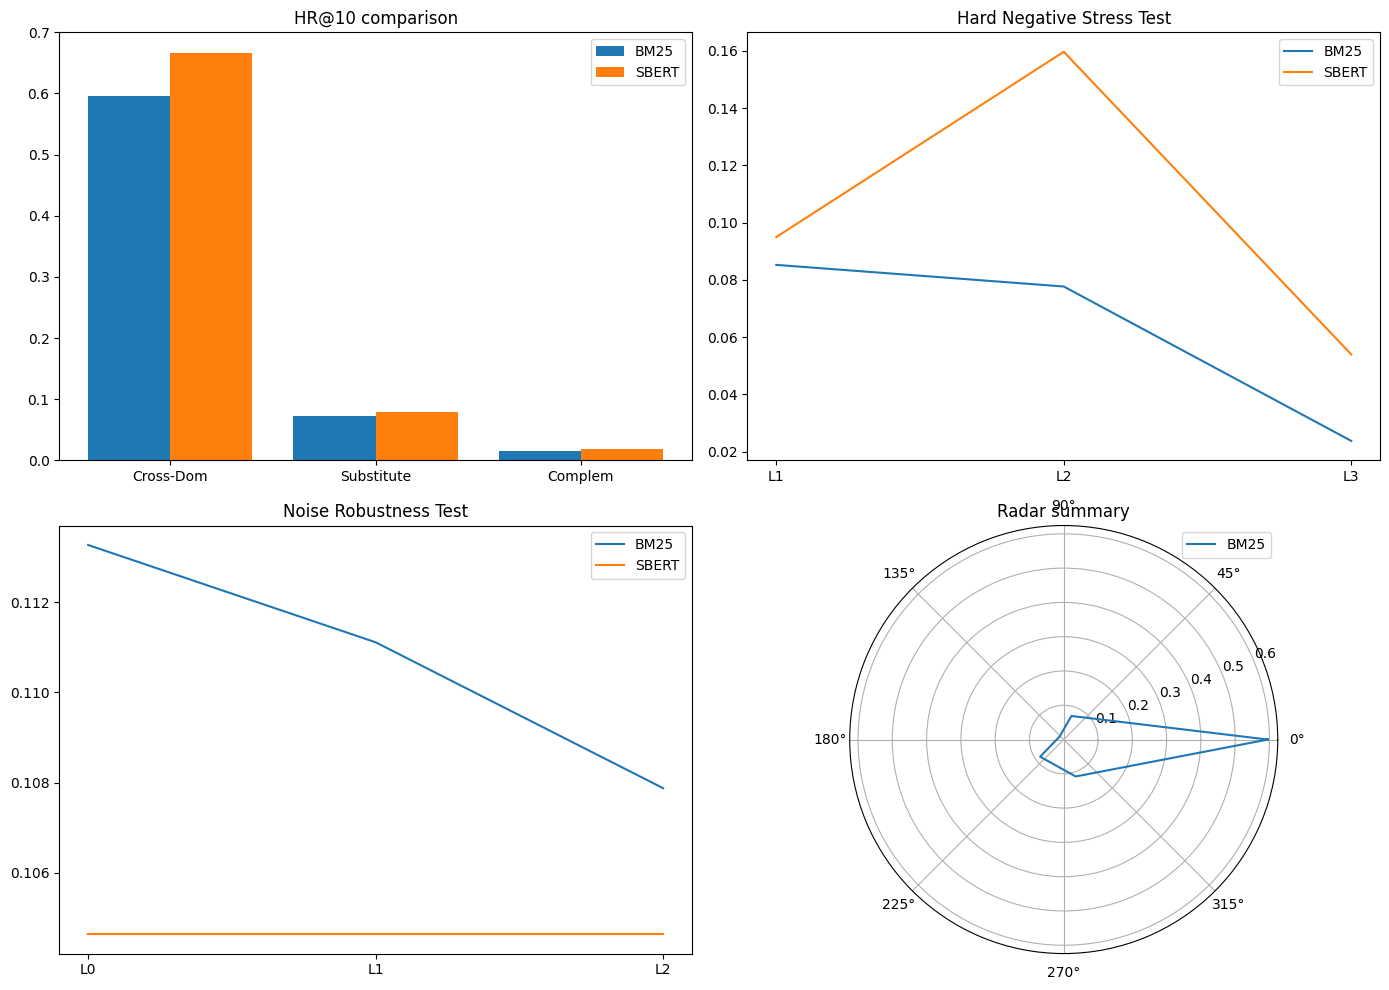

In [20]:
# CELL 19: TRỰC QUAN HÓA SO SÁNH
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sc_labels = ['Cross-Dom', 'Substitute', 'Complem']
bm25_vals = [scenarios_summary[0][2], scenarios_summary[1][2], scenarios_summary[2][2]]
sbert_vals = [scenarios_summary[0][3], scenarios_summary[1][3], scenarios_summary[2][3]]
x = np.arange(len(sc_labels))
axs[0, 0].bar(x - 0.2, bm25_vals, 0.4, label='BM25')
axs[0, 0].bar(x + 0.2, sbert_vals, 0.4, label='SBERT')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(sc_labels)
axs[0, 0].legend()
axs[0, 0].set_title("HR@10 comparison")

axs[0, 1].plot(['L1', 'L2', 'L3'], [scenarios_summary[3][2], scenarios_summary[4][2], scenarios_summary[5][2]], label='BM25')
axs[0, 1].plot(['L1', 'L2', 'L3'], [scenarios_summary[3][3], scenarios_summary[4][3], scenarios_summary[5][3]], label='SBERT')
axs[0, 1].legend()
axs[0, 1].set_title("Hard Negative Stress Test")

axs[1, 0].plot(['L0', 'L1', 'L2'], [scenarios_summary[6][2], scenarios_summary[7][2], scenarios_summary[8][2]], label='BM25')
axs[1, 0].plot(['L0', 'L1', 'L2'], [scenarios_summary[6][3], scenarios_summary[7][3], scenarios_summary[8][3]], label='SBERT')
axs[1, 0].legend()
axs[1, 0].set_title("Noise Robustness Test")

axs[1, 1].remove()
ax_polar = fig.add_subplot(2, 2, 4, projection='polar')
angles = np.linspace(0, 2*np.pi, 5, endpoint=False).tolist()
angles += angles[:1]
radar_vals = bm25_vals + [scenarios_summary[3][2], scenarios_summary[6][2]]
radar_vals += radar_vals[:1]
ax_polar.plot(angles, radar_vals, label='BM25')
ax_polar.legend()
ax_polar.set_title("Radar summary")

plt.tight_layout()
plt.savefig('benchmark_charts.png')
plt.show()

In [21]:
# CELL 20: XUẤT BÁO CÁO CUỐI CÙNG
summary_df = pd.DataFrame(scenarios_summary, columns=['Scenario_Num', 'Scenario_Name', 'BM25_HR', 'SBERT_HR', 'Hybrid_HR', 'CHGNN_HR'])
summary_df.to_csv('benchmark_results_summary.csv', index=False)

with open('benchmark_report.md', 'w', encoding='utf-8') as f:
    f.write("# REPORT BENCHMARK RESULTS\n\n")
    f.write(summary_df.to_markdown(index=False))

print("Saved all reports: benchmark_results_summary.csv, benchmark_charts.png, benchmark_report.md")

Saved all reports: benchmark_results_summary.csv, benchmark_charts.png, benchmark_report.md
